## Лабораторная работ №1 по дисциплине "Машинное обуычение и распознование образов"
### Выполнили Богачев М.И. и Чумаков И.И. гр 6511 
### Вариант 3
**Цель работы** – подготовка экспериментального материала
для решения задач распознавания образов, получение навыков работы на языке Python.

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [29]:
def get_normal_vector(M: np.ndarray, B: np.ndarray, show_print: bool = False) -> np.ndarray:
    A = np.zeros((2, 2))
    A[0, 0] = np.sqrt(B[0, 0])
    A[1, 0] = B[0, 1] / A[0, 0]
    A[1, 1] = np.sqrt(B[1, 1] - np.power(A[1, 0], 2))

    # norm_data = norm.rvs(loc=0, scale=1, size=2)
    # r = np.random.uniform(0, 1, 2)

    E = np.zeros((2, 1))
    n = 100000
    a = 0
    b = 1
    for i in range(n):
        uni = np.array(np.random.uniform(a, b, 2))
        E += uni.reshape(2,1)   
    E /= np.sqrt(n)
    # print(E)
    
    # z1 = np.sqrt(-2*np.log(r[0])) * np.cos(2*np.pi*r[1])
    # z2 = np.sqrt(-2*np.log(r[0])) * np.sin(2*np.pi*r[1])

    # E = np.array([[z1],
    #               [z2]])

    # E = np.array([[norm_data[0]], 
    #               [norm_data[1]]])
    
    X = np.dot(A, E) + M

    if show_print:
        print("M: \n", M)
        print("B: \n", B)
        print("A: \n", A)
        print("E: \n", E)

    return X

In [ ]:
# Исходные данные для 3 варианта

M1 = np.array([0.0, 0.0])   # пример — ЗАМЕНИ на свой вариант
M2 = np.array([-1.0, 1.0])   # пример — ЗАМЕНИ на свой вариант
M3 = np.array([-1.0, -1.0])

N = 200

# Разные ковариационные матрицы (все симм. и положительно определённые)
B1 = np.array([[1.0,  0.3],
               [0.3,  0.8]])
B2 = np.array([[1.4, -0.2],
               [-0.2, 0.9]])
B3 = np.array([[0.6,  0.45],
               [0.45, 1.5]])

repA = np.array([
    [0,1,0,0,0,0,1,0,0],
    [0,1,0,0,0,1,0,0,0],
    [0,1,0,0,1,0,0,0,0],
    [0,1,0,1,0,0,0,0,0],
    [0,1,1,0,0,0,0,0,0],
    [0,1,0,1,0,0,0,0,0],
    [0,1,0,0,1,0,0,0,0],
    [0,1,0,0,0,1,0,0,0],
    [0,1,0,0,0,0,1,0,0],
], dtype=int)

repB = np.array([
    [0,1,1,1,1,1,1,0,0],
    [0,1,0,0,0,0,0,0,0],
    [0,1,0,0,0,0,0,0,0],
    [0,1,0,0,0,0,0,0,0],
    [0,1,0,0,0,0,0,0,0],
    [0,1,0,0,0,0,0,0,0],
    [0,1,0,0,0,0,0,0,0],
    [0,1,0,0,0,0,0,0,0],
    [0,1,0,0,0,0,0,0,0],
], dtype=int)

1. Разработать алгоритм моделирования нормально распределенного случайного вектора с заданными математическим
ожиданием и корреляционной матрицей.

In [31]:
import numpy as np

def generate_normal_vector(mean, cov, n_samples=1, random_state=None):
    """
    Генерация нормально распределённых случайных векторов с использованием
    центральной предельной теоремы и равномерного распределения.

    Параметры:
    mean : array-like, shape (d,)
        Вектор математических ожиданий.
    cov : array-like, shape (d,d)
        Ковариационная матрица.
    n_samples : int
        Количество генерируемых векторов.
    random_state : int или None
        Сид генератора для воспроизводимости.

    Возвращает:
    samples : np.ndarray, shape (n_samples, d)
        Сгенерированные нормально распределённые векторы.
    """
    rng = np.random.default_rng(random_state)
    mean = np.asarray(mean)
    cov = np.asarray(cov)
    d = mean.shape[0]

    # Разложение Холецкого: cov = L @ L.T
    L = np.linalg.cholesky(cov)

    # Генерация стандартных нормальных векторов с использованием ЦПТ
    # (сумма 12 равномерных [0, 1) минус 6 ≈ нормальное распределение с μ=0, σ²=1)
    z = rng.uniform(0, 1, size=(n_samples, d, 12))
    z = np.sum(z, axis=2) - 6  # shape (n_samples, d)

    # Преобразуем z в нужное распределение: x = z @ L.T + mean
    samples = z @ L.T + mean

    return samples

In [32]:
# Пример: двумерный случайный вектор
M = [0, 1]   # вектор математических ожиданий
B = [[1, 0.5],
     [0.5, 2]]  # ковариационная матрица

X = generate_normal_vector(M, B, n_samples=1000, random_state=42)
print("Примеры случайных векторов:\n", X)

Примеры случайных векторов:
 [[ 1.26186673  3.20702081]
 [-0.61153046  0.82340336]
 [-0.75082785  0.11109555]
 ...
 [ 0.94964615 -1.04583839]
 [ 0.23463458  1.93711917]
 [ 0.45110365  2.64901362]]


2. Смоделировать и изобразить графически обучающие выборки
объема N=200 для двух нормально распределенных двумерных случайных векторов с заданными математическими ожиданиями и самостоятельно подобранными равными корреляционными матрицами. 

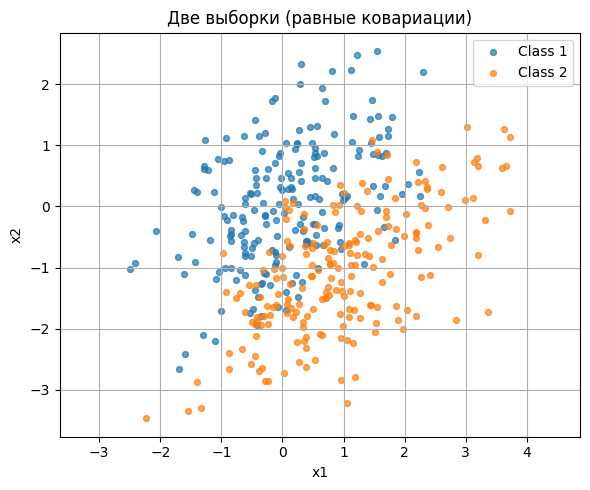

Сохранено:
data/X1_equal_cov.npy (200, 2)
data/X2_equal_cov.npy (200, 2)


In [33]:

# равные ковариационные матрицы (должна быть симм. и положительно определённой)
B_equal = np.array([[1.2, 0.6],
                    [0.6, 1.0]])

X1 = generate_normal_vector(M1, B_equal, n_samples=N)
X2 = generate_normal_vector(M2, B_equal, n_samples=N)

# Сохранение в .npy 
Path("data").mkdir(exist_ok=True)
np.save("data/X1_equal_cov.npy", X1)
np.save("data/X2_equal_cov.npy", X2)

# Визуализация
plt.figure(figsize=(6, 5))
plt.scatter(X1[:, 0], X1[:, 1], alpha=0.7, label="Class 1", s=18)
plt.scatter(X2[:, 0], X2[:, 1], alpha=0.7, label="Class 2", s=18)
plt.xlabel("x1"); plt.ylabel("x2"); plt.title("Две выборки (равные ковариации)")
plt.legend(); plt.grid(True); plt.axis("equal")
plt.tight_layout()
plt.show()

print("Сохранено:")
print("data/X1_equal_cov.npy", X1.shape)
print("data/X2_equal_cov.npy", X2.shape)


3. Смоделировать и изобразить графически обучающие выборки
объема N=200 для трех нормально распределенных двумерных случайных векторов с заданными математическими ожиданиями и с неравными корреляционными матрицами, которые выбрать самостоятельно. 

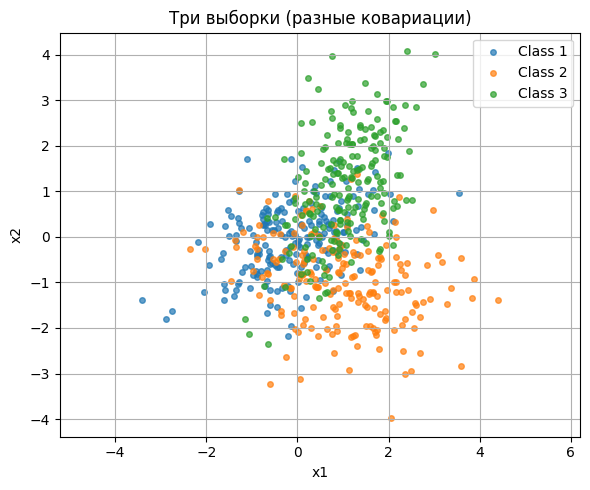

Сохранено:
  data/X1_unequal_cov.npy (200, 2)
  data/X2_unequal_cov.npy (200, 2)
  data/X3_unequal_cov.npy (200, 2)


In [34]:
# === Задание 3 ===
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def generate_normal_vector(mean, cov, n_samples=1, random_state=None):
    rng = np.random.default_rng(random_state)
    return rng.multivariate_normal(mean, cov, size=n_samples)

N = 200

X1 = generate_normal_vector(M1, B1, n_samples=N)
X2 = generate_normal_vector(M2, B2, n_samples=N)
X3 = generate_normal_vector(M3, B3, n_samples=N)

# Сохранение
Path("data").mkdir(exist_ok=True)
np.save("data/X1_unequal_cov.npy", X1)
np.save("data/X2_unequal_cov.npy", X2)
np.save("data/X3_unequal_cov.npy", X3)

# Визуализация
plt.figure(figsize=(6, 5))
plt.scatter(X1[:, 0], X1[:, 1], alpha=0.7, label="Class 1", s=16)
plt.scatter(X2[:, 0], X2[:, 1], alpha=0.7, label="Class 2", s=16)
plt.scatter(X3[:, 0], X3[:, 1], alpha=0.7, label="Class 3", s=16)
plt.xlabel("x1"); plt.ylabel("x2"); plt.title("Три выборки (разные ковариации)")
plt.legend(); plt.grid(True); plt.axis("equal")
plt.tight_layout()
plt.show()

print("Сохранено:")
print("  data/X1_unequal_cov.npy", X1.shape)
print("  data/X2_unequal_cov.npy", X2.shape)
print("  data/X3_unequal_cov.npy", X3.shape)


4. На основании полученных выборок найти точечные оценки
параметров нормального закона для каждого из распределений. 

In [35]:
# Загрузим любые выборки, для которых хотим оценки
X1 = np.load("data/X1_equal_cov.npy")   # можно поменять на наборы из задания 3
X2 = np.load("data/X2_equal_cov.npy")

def mle_mean_cov(X):
    """
    Оценки максимального правдоподобия для M и B (ковариационной матрицы).
    По методичке: 
      M_hat = 1/N * sum x_i,
      B_hat = 1/N * sum (x_i - M_hat)(x_i - M_hat)^T
    """
    M_hat = X.mean(axis=0)
    Xc = X - M_hat
    B_hat = (Xc.T @ Xc) / X.shape[0]
    return M_hat, B_hat

def mahalanobis_distance(M0, M1, B):
    """ρ_M = (M1 - M0)^T B^{-1} (M1 - M0)  (для равных ковариаций)"""
    d = M1 - M0
    Binv = np.linalg.inv(B)
    return float(d.T @ Binv @ d)

def bhattacharyya_distance(M0, B0, M1, B1):
    """
    ρ_B = (1/8)(M1 - M0)^T B^{-1} (M1 - M0) + (1/2) ln( det(B)/sqrt(det(B0)det(B1)) )
    где B = (B0 + B1)/2
    """
    B = 0.5 * (B0 + B1)
    Binv = np.linalg.inv(B)
    dM = (M1 - M0).reshape(-1, 1)
    term1 = 0.125 * float(dM.T @ Binv @ dM)
    det_B = np.linalg.det(B)
    det_B0 = np.linalg.det(B0)
    det_B1 = np.linalg.det(B1)
    term2 = 0.5 * np.log(det_B / np.sqrt(det_B0 * det_B1))
    return float(term1 + term2)

# Оценки по выборкам
M1_hat, B1_hat = mle_mean_cov(X1)
M2_hat, B2_hat = mle_mean_cov(X2)

print("Оценки по X1:")
print("  M1_hat =", M1_hat)
print("  B1_hat =\n", B1_hat)
print("\nОценки по X2:")
print("  M2_hat =", M2_hat)
print("  B2_hat =\n", B2_hat)

# Метрики близости
# Если предполагаем равные ковариации, можно взять усреднённую оценку или истинную (если знаем)
B_equal_hat = 0.5 * (B1_hat + B2_hat)
rho_maha = mahalanobis_distance(M1_hat, M2_hat, B_equal_hat)
rho_bhat = bhattacharyya_distance(M1_hat, B1_hat, M2_hat, B2_hat)

print("\n Расстояния между X1 и X2:")
print("Махаланобиса (ρ_M) =", rho_maha)
print("Бхатачария (ρ_B)   =", rho_bhat)


Оценки по X1:
  M1_hat = [0.07021168 0.04083086]
  B1_hat =
 [[0.87712722 0.42447414]
 [0.42447414 1.00338002]]

Оценки по X2:
  M2_hat = [ 0.95273251 -1.06798882]
  B2_hat =
 [[1.29465035 0.70197542]
 [0.70197542 0.99803791]]

 Расстояния между X1 и X2:
Махаланобиса (ρ_M) = 4.1806821807953085
Бхатачария (ρ_B)   = 0.5367284468853062


C:\Users\maestromezer\AppData\Local\Temp\ipykernel_6452\196884782.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  term1 = 0.125 * float(dM.T @ Binv @ dM)


5. Смоделировать обучающие выборки объема N=200 двух бинарных случайных векторов с распределениями, которые
обеспечивают вероятность изменения указанной в представителе компоненты случайного вектора, равной
p=0.3 . 

Сохранено:
  data/bin_images_repA_allmask.npy (200, 9, 9)
  data/bin_images_repB_allmask.npy (200, 9, 9)
Средняя доля изменённых пикселей для repA: 0.295 (ожидаемо ~ 0.3)
Средняя доля изменённых пикселей для repB: 0.303 (ожидаемо ~ 0.3)


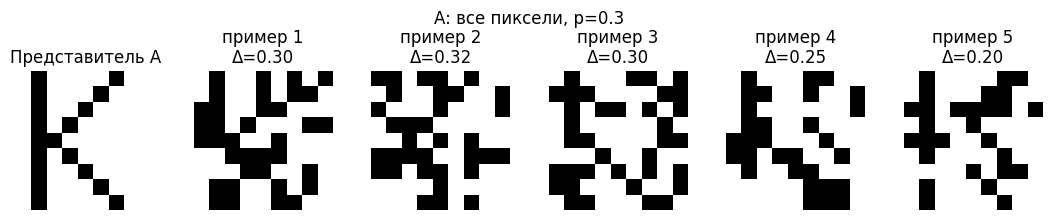

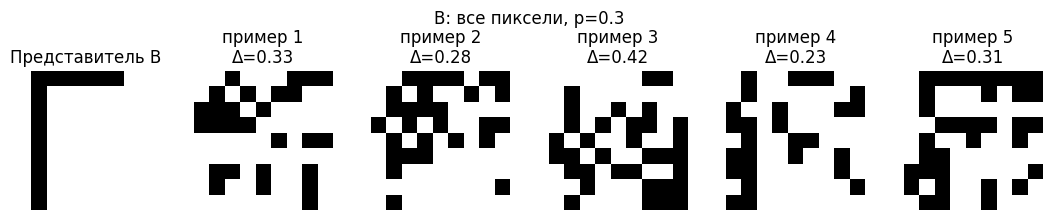

In [36]:
# === ЛР1 — Пункт 5: разрешаем менять ВСЕ пиксели (p=0.3) ===
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------- ПАРАМЕТРЫ ----------------
N = 200
p = 0.3

assert repA.shape == (9,9) and repB.shape == (9,9)

# ---------------- МАСКИ: ВСЕ ПИКСЕЛИ ----------------
mask_all = np.ones((9,9), dtype=bool)
maskA = mask_all
maskB = mask_all

# ---------------- ФУНКЦИЯ ГЕНЕРАЦИИ ----------------
def generate_binary_images(rep_matrix, change_mask, p=0.3, n_samples=200, random_state=None):
    rng = np.random.default_rng(random_state)
    rep = np.array(rep_matrix, dtype=int)
    d1, d2 = rep.shape
    X = np.tile(rep, (n_samples, 1, 1))
    flips = rng.uniform(0, 1, size=(n_samples, d1, d2)) < p
    flips &= change_mask
    X[flips] = 1 - X[flips]
    return X

# ---------------- ГЕНЕРАЦИЯ ----------------
XA = generate_binary_images(repA, maskA, p=p, n_samples=N)
XB = generate_binary_images(repB, maskB, p=p, n_samples=N)

# ---------------- СОХРАНЕНИЕ ----------------
Path("data").mkdir(exist_ok=True)
np.save("data/bin_images_repA_allmask.npy", XA)
np.save("data/bin_images_repB_allmask.npy", XB)

# ---------------- МЕТРИКИ ----------------
# Средняя доля изменённых пикселей (Хэмминга на пиксель) относительно представителя
def avg_flip_fraction(X, rep):
    diffs = (X != rep)  # (N, 9, 9) булево
    return diffs.mean() # средняя по всем сэмплам и пикселям

rateA = avg_flip_fraction(XA, repA)
rateB = avg_flip_fraction(XB, repB)

print("Сохранено:")
print("  data/bin_images_repA_allmask.npy", XA.shape)
print("  data/bin_images_repB_allmask.npy", XB.shape)
print(f"Средняя доля изменённых пикселей для repA: {rateA:.3f} (ожидаемо ~ {p})")
print(f"Средняя доля изменённых пикселей для repB: {rateB:.3f} (ожидаемо ~ {p})")

# ---------------- ВИЗУАЛИЗАЦИЯ ----------------
def show_samples(rep, X, title_rep="Представитель", title_set="Примеры (все пиксели могут инвертироваться)"):
    k = 5  # покажем 5 примеров
    plt.figure(figsize=(1.8*(k+1), 2.2))
    # представитель
    plt.subplot(1, k+1, 1)
    plt.imshow(rep, cmap="gray_r", vmin=0, vmax=1)
    plt.title(title_rep)
    plt.axis('off')
    # примеры
    for i in range(k):
        plt.subplot(1, k+1, i+2)
        plt.imshow(X[i], cmap="gray_r", vmin=0, vmax=1)
        # подпись: доля изменённых пикселей в примере i
        diff_frac = (X[i] != rep).mean()
        plt.title(f"пример {i+1}\nΔ={diff_frac:.2f}")
        plt.axis('off')
    plt.suptitle(title_set)
    plt.tight_layout()
    plt.show()

show_samples(repA, XA, title_rep="Представитель A", title_set=f"A: все пиксели, p={p}")
show_samples(repB, XB, title_rep="Представитель B", title_set=f"B: все пиксели, p={p}")
